In [2]:
import numpy as np
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import mrestimator as mre

import sys
sys.path.insert(0,'../experiment_analysis/ana/')

from hdestimator import utils as utl

In [3]:
# Import the data

mat = scipy.io.loadmat('SPP2205.mat')

# trying to figure out which column is what
n_id = 1
spikes = mat["data"][0][n_id][0]
status = mat["data"][0][n_id][2][0]
readout_n_id = mat["data"][0][n_id][3] # maybe?

# create a dict for every neuron
prepped = dict()
data = mat["data"][0]


prepped[n_id] = dict()
for n_id in range(0, len(data)):
    prepped[n_id] = dict()
    prepped[n_id]["spike_times"] = data[n_id][0].flatten()
    prepped[n_id]["region"] = data[n_id][1][0]
    prepped[n_id]["status"] = data[n_id][2][0]
    prepped[n_id]["clusterID"] = data[n_id][3][0,0]
    prepped[n_id]["channel"] = data[n_id][4][0,0]


# Further metrics
bin_size = 5E-3 # bin size 5 ms

for n_id in range(0, len(data)):
    prepped[n_id]['binned_spikes'] = utl.get_binned_neuron_activity(prepped[n_id]["spike_times"], bin_size) 
    prepped[n_id]['firing_rate'] = utl.get_binned_firing_rate(prepped[n_id]["spike_times"], bin_size) 

spike_times = [prepped[id]["spike_times"] for id in range(len(prepped))]

analysis: 0000, hde v. 0.10b2, 2025-02-25
pid_7097
recording length: 1166.5s
recording length sd: 0.0s
firing rate: 17.8Hz
firing rate sd: 0.0Hz

Shuffling
---------------------------------------------------------------
T_D [s]: 0.035
tau_R [s]: 0.007
R_tot: 0.009
R_tot, 95% CI: [nan, nan]
opt. d: 5
opt. kappa: 0.070
opt. tau_1 [s]: 0.005

BBC
---------------------------------------------------------------
T_D [s]: 0.056
tau_R [s]: 0.007
R_tot: 0.009
R_tot, 95% CI: [nan, nan]
opt. d: 5
opt. kappa: 0.150
opt. tau_1 [s]: 0.005
Saved image to /tmp/hde_analysis_test01_71oq_/ANALYSIS0000/0000.pdf


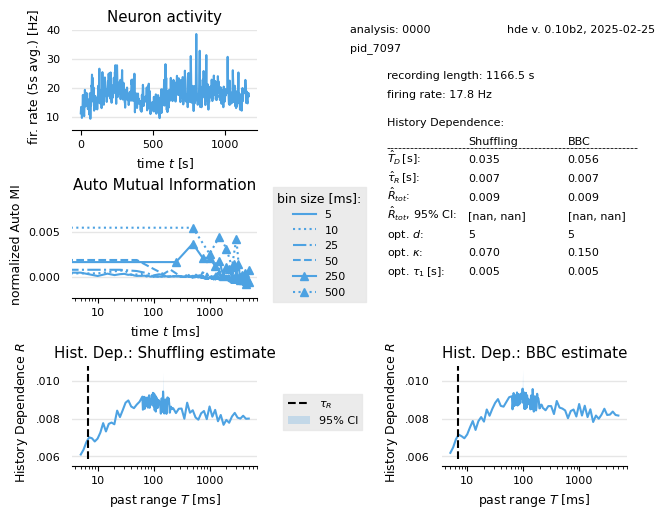

In [4]:
from hdestimator_wrapper_mr import hde
args = {}
args['estimation_method'] = 'all'


res = hde(spike_times[1]  , cli_args=args)

plt.figure(figsize=(30,15))
for i, data in enumerate(spike_times):
    if prepped[i]["status"] == 'good': color='g'
    else: color='r'
    plt.scatter(data, np.ones_like(data)*i, marker='|', color=color, alpha=.5)


plt.xlabel('time (s)')
plt.ylabel('unit')
plt.xlim(0,50)
plt.ylim(0,236)
plt.title("Activity")

red_patch = mpl.patches.Patch(color='red', label='#multi unit=81')
green_patch = mpl.patches.Patch(color='g', label='#good=155')
plt.legend(title="status", handles=[green_patch, red_patch])

Text(0, 0.5, '#spikes')

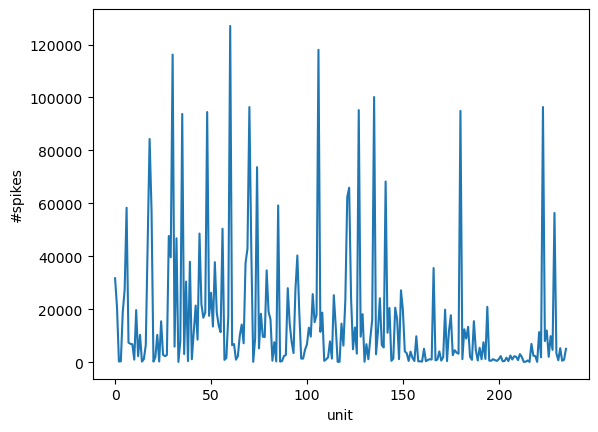

In [ ]:
# Check number of entries per unit
plt.plot([len(arr) for arr in spike_times])
plt.xlabel("unit")
plt.ylabel("#spikes")

Text(0, 0.5, '#NaN')

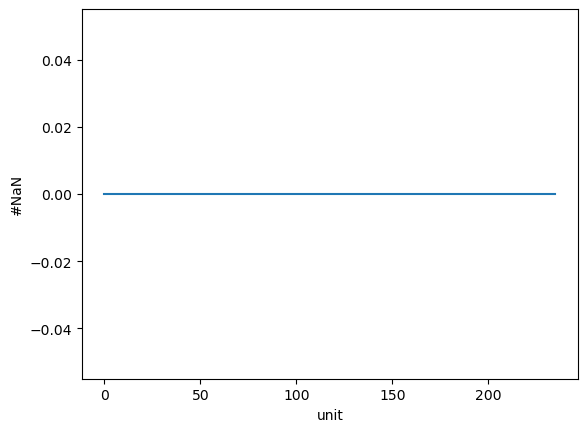

In [ ]:
# Check for NaNs
plt.plot([sum(np.isnan(arr)) for arr in spike_times])
plt.xlabel("unit")
plt.ylabel("#NaN")

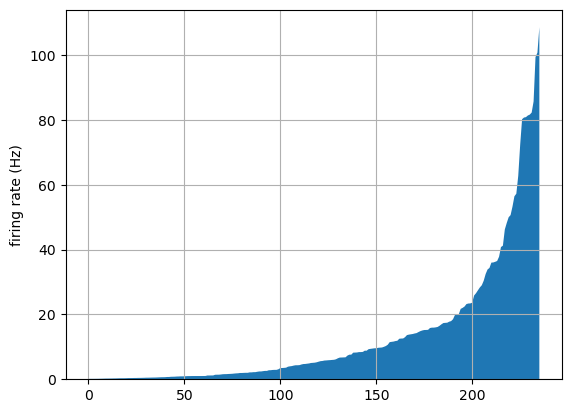

In [ ]:
firing_rates = [utl.get_binned_firing_rate(train, bin_size) for train in spike_times]
firing_rates = sorted(firing_rates)

plt.fill_between(np.arange(len(firing_rates)), firing_rates)
plt.ylabel("firing rate (Hz)")
plt.ylim(0)
plt.grid()

In [ ]:
%load_ext autoreload
%autoreload 2

>>> shuffling
analysis: 0001, hde v. 0.10b2, 2025-02-24
pid_24476
recording length: 1166.5s
recording length sd: 0.0s
firing rate: 17.8Hz
firing rate sd: 0.0Hz

Shuffling
---------------------------------------------------------------
T_D [s]: 0.056
tau_R [s]: 0.007
R_tot: 0.009
R_tot, 95% CI: [nan, nan]
opt. d: 5
opt. kappa: 0.150
opt. tau_1 [s]: 0.005

BBC
---------------------------------------------------------------
T_D [s]: nan
tau_R [s]: nan
R_tot: nan
R_tot, 95% CI: [nan, nan]
opt. d: nan
opt. kappa: nan
opt. tau_1 [s]: nan
Saved image to ./analysis/ANALYSIS0001/0001.pdf


KeyError: 'analysis_dir'

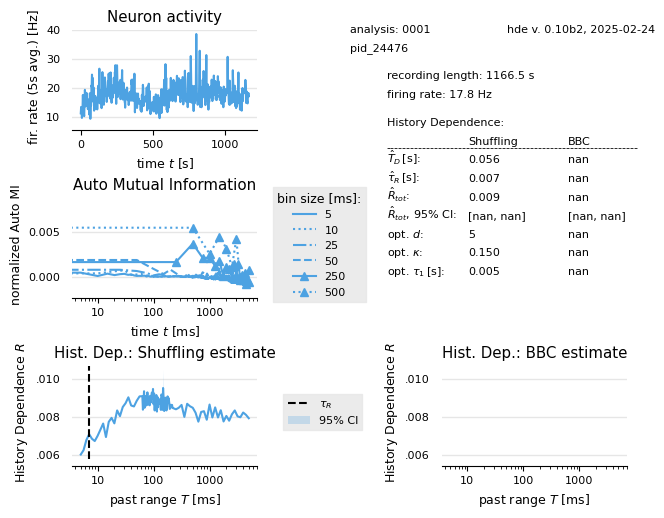

In [ ]:
print(args)

{'estimation_method': 'bbc'}
